# Praktikum Hierarchical Clustering
**Nama:** Mikhael Josua  
**NIM:** 42324023       
**Prodi:** D3 Teknologi Informasi  

## 1. Import pustaka
NumPy dan Pandas digunakan untuk data; SciPy untuk matriks jarak, linkage, dan dendrogram; StandardScaler untuk menstandarkan fitur pelanggan. Hierarki ditentukan oleh data dan aturan linkage, sehingga tidak membutuhkan `random_state`.

In [1]:
# Jalankan bila pustaka belum tersedia:
# %pip install numpy pandas scipy matplotlib scikit-learn

from pathlib import Path
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 2. Percobaan pertama - dataset sederhana
Enam titik a–f diambil persis dari modul. Kedua koordinat dipakai langsung tanpa scaling, agar perhitungan jarak sesuai dengan percobaan pertama.

In [2]:
data = np.array([
    [1.0, 1.0],  # a
    [1.5, 1.5],  # b
    [5.0, 5.0],  # c
    [3.0, 4.0],  # d
    [4.0, 4.0],  # e
    [3.0, 3.5],  # f
])
point_labels = list("abcdef")
display(pd.DataFrame(data, columns=["X", "Y"], index=point_labels))

,X,Y
a,1.0,1.0
b,1.5,1.5
c,5.0,5.0
d,3.0,4.0
e,4.0,4.0
f,3.0,3.5


## 3. Matriks jarak Euclidean
Jarak Euclidean dihitung dengan rumus $d(p,q)=\sqrt{\sum_j(p_j-q_j)^2}$. Matriks bersifat simetris dan diagonalnya nol. Pasangan dengan jarak terkecil akan digabung terlebih dahulu.

In [3]:
condensed_distances = pdist(data, metric="euclidean")
distance_matrix = squareform(condensed_distances)
distance_df = pd.DataFrame(distance_matrix, index=point_labels, columns=point_labels)
print("=== Distance Matrix (Euclidean) ===")
display(distance_df.round(6))

# Pemeriksaan independen terhadap rumus Euclidean.
manual_distances = np.sqrt(((data[:, None, :] - data[None, :, :]) ** 2).sum(axis=2))
assert np.allclose(distance_matrix, manual_distances)
assert np.allclose(distance_matrix, distance_matrix.T)
assert np.allclose(np.diag(distance_matrix), 0)
assert np.isclose(distance_df.loc["d", "f"], 0.5)
assert np.isclose(distance_df.loc["a", "b"], np.sqrt(0.5))

=== Distance Matrix (Euclidean) ===


,a,b,c,d,e,f
a,0.000000,0.707107,5.656854,3.605551,4.242641,3.201562
b,0.707107,0.000000,4.949747,2.915476,3.535534,2.500000
c,5.656854,4.949747,0.000000,2.236068,1.414214,2.500000
d,3.605551,2.915476,2.236068,0.000000,1.000000,0.500000
e,4.242641,3.535534,1.414214,1.000000,0.000000,1.118034
f,3.201562,2.500000,2.500000,0.500000,1.118034,0.000000


## 4. Dendrogram single linkage sesuai modul
Single linkage menggunakan jarak **minimum** antar pasangan titik dari dua klaster. Sumbu vertikal menyatakan jarak saat klaster digabung; posisi horizontal hanya urutan daun, bukan jarak antartitik.

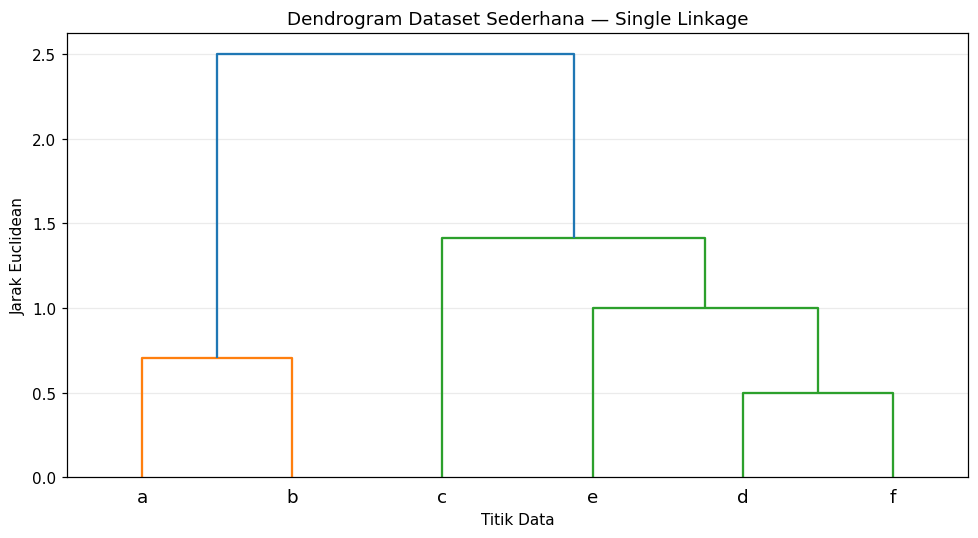

In [4]:
linked_single = linkage(data, method="single", metric="euclidean")
fig, ax = plt.subplots(figsize=(9, 5))
dendrogram(linked_single, labels=point_labels, ax=ax)
ax.set(title="Dendrogram Dataset Sederhana — Single Linkage",
       xlabel="Titik Data", ylabel="Jarak Euclidean")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Jawaban tugas - perbandingan tiga metode linkage
Ketiga metode memakai **dataset dan metrik Euclidean yang sama**; yang berbeda adalah aturan jarak antarklaster.

| Metode | Jarak antarklaster | Karakteristik umum |
| --- | --- | --- |
| Single | Jarak pasangan titik paling dekat | Dapat membentuk rantai (*chaining*) |
| Complete | Jarak pasangan titik paling jauh | Cenderung membentuk kelompok lebih kompak |
| Average | Rata-rata jarak seluruh pasangan lintas klaster | Kompromi antara kedekatan lokal dan sebaran kelompok |

Plot memakai rentang sumbu vertikal yang sama agar tinggi penggabungan dapat dibandingkan secara adil. Warna cabang hanya membantu membaca dendrogram, bukan label kelompok yang universal.

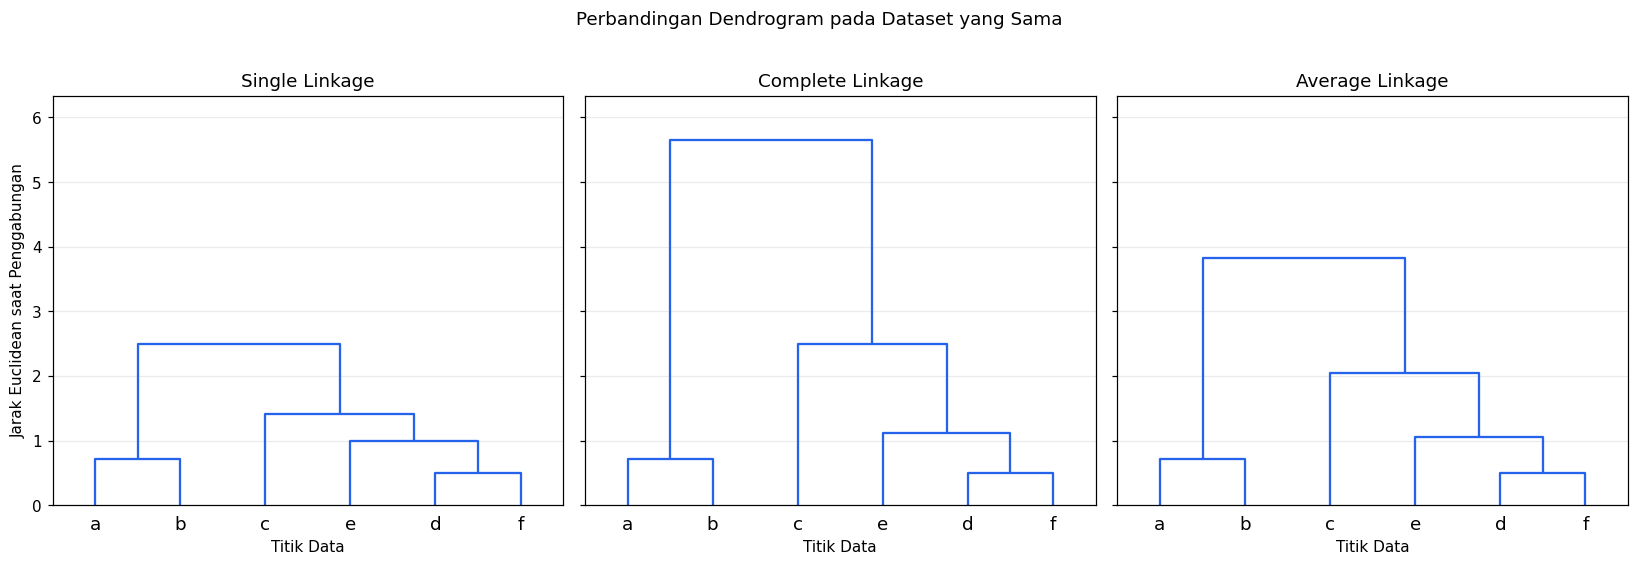

In [5]:
methods = ["single", "complete", "average"]
linkages = {m: linkage(data, method=m, metric="euclidean") for m in methods}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
max_height = max(z[-1, 2] for z in linkages.values())
for ax, method in zip(axes, methods):
    dendrogram(linkages[method], labels=point_labels,
               color_threshold=0, above_threshold_color="#2563eb", ax=ax)
    ax.set(title=f"{method.capitalize()} Linkage",
           xlabel="Titik Data", ylim=(0, max_height * 1.12))
    ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel("Jarak Euclidean saat Penggabungan")
fig.suptitle("Perbandingan Dendrogram pada Dataset yang Sama", y=1.02)
fig.tight_layout()
plt.show()

### Urutan dan tinggi penggabungan
Tabel berikut menampilkan anggota klaster yang digabung pada setiap tahap. Untuk membandingkan struktur kelompok, masing-masing hierarki juga dipotong menjadi tepat tiga klaster. Pemotongan ini hanya ilustrasi dan bukan klaim bahwa tiga merupakan jumlah optimal.

In [6]:
def merge_steps(z, labels):
    members = {i: [label] for i, label in enumerate(labels)}
    rows = []
    for step, (left, right, height, size) in enumerate(z, start=1):
        left, right = int(left), int(right)
        joined = sorted(members[left] + members[right])
        rows.append({
            "Tahap": step,
            "Klaster Kiri": "{" + ", ".join(members[left]) + "}",
            "Klaster Kanan": "{" + ", ".join(members[right]) + "}",
            "Jarak Gabung": float(height),
            "Jumlah Titik": int(size),
        })
        members[len(labels) + step - 1] = joined
    return pd.DataFrame(rows)

comparison_rows = []
toy_groupings = {}
for method in methods:
    print(f"=== {method.upper()} LINKAGE ===")
    display(merge_steps(linkages[method], point_labels).round(6))
    assignments = cut_tree(linkages[method], n_clusters=3).ravel()
    groups = [
        "{" + ", ".join(np.array(point_labels)[assignments == cluster]) + "}"
        for cluster in np.unique(assignments)
    ]
    toy_groupings[method] = groups
    comparison_rows.append({
        "Metode": method,
        "Tinggi Penggabungan Terakhir": linkages[method][-1, 2],
        "Kelompok saat k=3": " | ".join(groups),
    })
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(6))

=== SINGLE LINKAGE ===


,Tahap,Klaster Kiri,Klaster Kanan,Jarak Gabung,Jumlah Titik
0,1,{d},{f},0.500000,2
1,2,{a},{b},0.707107,2
2,3,{e},"{d, f}",1.000000,3
3,4,{c},"{d, e, f}",1.414214,4
4,5,"{a, b}","{c, d, e, f}",2.500000,6


=== COMPLETE LINKAGE ===


,Tahap,Klaster Kiri,Klaster Kanan,Jarak Gabung,Jumlah Titik
0,1,{d},{f},0.500000,2
1,2,{a},{b},0.707107,2
2,3,{e},"{d, f}",1.118034,3
3,4,{c},"{d, e, f}",2.500000,4
4,5,"{a, b}","{c, d, e, f}",5.656854,6


=== AVERAGE LINKAGE ===


,Tahap,Klaster Kiri,Klaster Kanan,Jarak Gabung,Jumlah Titik
0,1,{d},{f},0.500000,2
1,2,{a},{b},0.707107,2
2,3,{e},"{d, f}",1.059017,3
3,4,{c},"{d, e, f}",2.050094,4
4,5,"{a, b}","{c, d, e, f}",3.825921,6


,Metode,Tinggi Penggabungan Terakhir,Kelompok saat k=3
0,single,2.500000,"{a, b} | {c} | {d, e, f}"
1,complete,5.656854,"{a, b} | {c} | {d, e, f}"
2,average,3.825921,"{a, b} | {c} | {d, e, f}"


### Pembahasan singkat hasil tugas
- Ketiga metode pertama-tama menggabungkan **d–f** (jarak 0,5) dan kemudian **a–b** (sekitar 0,7071), karena pasangan tersebut paling dekat.
- **Single:** titik e bergabung dengan {d,f} melalui pasangan terdekat. Setelah itu c ikut bergabung; pola ini memperlihatkan kecenderungan membentuk rantai.
- **Complete:** e juga bergabung dengan {d,f}, tetapi tinggi penggabungannya memakai jarak maksimum, sekitar 1,1180. Nilai ini masih lebih kecil daripada jarak c–e (sekitar 1,4142), sehingga urutan penggabungannya tetap sama dengan single pada dataset ini.
- **Average:** e bergabung dengan {d,f}, seperti pada single, tetapi tinggi cabangnya memakai rata-rata seluruh jarak lintas klaster, bukan jarak minimum.
- Pada pemotongan **k=3**, ketiga metode menghasilkan kelompok yang sama, yaitu **{a,b}, {c}, {d,e,f}**. Jadi, perbedaan metode tidak selalu menyebabkan perbedaan anggota kelompok.
- Untuk data ini, penggabungan terakhir pada complete berada paling tinggi, single paling rendah, dan average di antaranya. Tinggi yang lebih besar **tidak otomatis berarti metode lebih baik**, karena definisi jaraknya berbeda.

**Jawaban inti:** pada dataset ini, ketiga metode memiliki urutan penggabungan dan struktur kelompok yang sama, tetapi tinggi cabangnya berbeda. Jika dipotong pada jarak yang sama, jumlah kelompok dapat berbeda. Pada dataset lain, pilihan linkage juga dapat mengubah urutan penggabungan serta anggota klaster.

## 6. Percobaan kedua - dataset Mall Customers
Percobaan memakai dua fitur sesuai modul: **Annual Income (k$)** dan **Spending Score (1–100)**. `CustomerID` hanya identitas, sedangkan usia dan gender tidak dipakai dalam pembentukan hierarki ini.

In [7]:
# Salinan persis dataset lampiran sebelumnya, bukan data sintetis.
CSV_EMBEDDED = 'CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)\n0001,Male,19,15,39\n0002,Male,21,15,81\n0003,Female,20,16,6\n0004,Female,23,16,77\n0005,Female,31,17,40\n0006,Female,22,17,76\n0007,Female,35,18,6\n0008,Female,23,18,94\n0009,Male,64,19,3\n0010,Female,30,19,72\n0011,Male,67,19,14\n0012,Female,35,19,99\n0013,Female,58,20,15\n0014,Female,24,20,77\n0015,Male,37,20,13\n0016,Male,22,20,79\n0017,Female,35,21,35\n0018,Male,20,21,66\n0019,Male,52,23,29\n0020,Female,35,23,98\n0021,Male,35,24,35\n0022,Male,25,24,73\n0023,Female,46,25,5\n0024,Male,31,25,73\n0025,Female,54,28,14\n0026,Male,29,28,82\n0027,Female,45,28,32\n0028,Male,35,28,61\n0029,Female,40,29,31\n0030,Female,23,29,87\n0031,Male,60,30,4\n0032,Female,21,30,73\n0033,Male,53,33,4\n0034,Male,18,33,92\n0035,Female,49,33,14\n0036,Female,21,33,81\n0037,Female,42,34,17\n0038,Female,30,34,73\n0039,Female,36,37,26\n0040,Female,20,37,75\n0041,Female,65,38,35\n0042,Male,24,38,92\n0043,Male,48,39,36\n0044,Female,31,39,61\n0045,Female,49,39,28\n0046,Female,24,39,65\n0047,Female,50,40,55\n0048,Female,27,40,47\n0049,Female,29,40,42\n0050,Female,31,40,42\n0051,Female,49,42,52\n0052,Male,33,42,60\n0053,Female,31,43,54\n0054,Male,59,43,60\n0055,Female,50,43,45\n0056,Male,47,43,41\n0057,Female,51,44,50\n0058,Male,69,44,46\n0059,Female,27,46,51\n0060,Male,53,46,46\n0061,Male,70,46,56\n0062,Male,19,46,55\n0063,Female,67,47,52\n0064,Female,54,47,59\n0065,Male,63,48,51\n0066,Male,18,48,59\n0067,Female,43,48,50\n0068,Female,68,48,48\n0069,Male,19,48,59\n0070,Female,32,48,47\n0071,Male,70,49,55\n0072,Female,47,49,42\n0073,Female,60,50,49\n0074,Female,60,50,56\n0075,Male,59,54,47\n0076,Male,26,54,54\n0077,Female,45,54,53\n0078,Male,40,54,48\n0079,Female,23,54,52\n0080,Female,49,54,42\n0081,Male,57,54,51\n0082,Male,38,54,55\n0083,Male,67,54,41\n0084,Female,46,54,44\n0085,Female,21,54,57\n0086,Male,48,54,46\n0087,Female,55,57,58\n0088,Female,22,57,55\n0089,Female,34,58,60\n0090,Female,50,58,46\n0091,Female,68,59,55\n0092,Male,18,59,41\n0093,Male,48,60,49\n0094,Female,40,60,40\n0095,Female,32,60,42\n0096,Male,24,60,52\n0097,Female,47,60,47\n0098,Female,27,60,50\n0099,Male,48,61,42\n0100,Male,20,61,49\n0101,Female,23,62,41\n0102,Female,49,62,48\n0103,Male,67,62,59\n0104,Male,26,62,55\n0105,Male,49,62,56\n0106,Female,21,62,42\n0107,Female,66,63,50\n0108,Male,54,63,46\n0109,Male,68,63,43\n0110,Male,66,63,48\n0111,Male,65,63,52\n0112,Female,19,63,54\n0113,Female,38,64,42\n0114,Male,19,64,46\n0115,Female,18,65,48\n0116,Female,19,65,50\n0117,Female,63,65,43\n0118,Female,49,65,59\n0119,Female,51,67,43\n0120,Female,50,67,57\n0121,Male,27,67,56\n0122,Female,38,67,40\n0123,Female,40,69,58\n0124,Male,39,69,91\n0125,Female,23,70,29\n0126,Female,31,70,77\n0127,Male,43,71,35\n0128,Male,40,71,95\n0129,Male,59,71,11\n0130,Male,38,71,75\n0131,Male,47,71,9\n0132,Male,39,71,75\n0133,Female,25,72,34\n0134,Female,31,72,71\n0135,Male,20,73,5\n0136,Female,29,73,88\n0137,Female,44,73,7\n0138,Male,32,73,73\n0139,Male,19,74,10\n0140,Female,35,74,72\n0141,Female,57,75,5\n0142,Male,32,75,93\n0143,Female,28,76,40\n0144,Female,32,76,87\n0145,Male,25,77,12\n0146,Male,28,77,97\n0147,Male,48,77,36\n0148,Female,32,77,74\n0149,Female,34,78,22\n0150,Male,34,78,90\n0151,Male,43,78,17\n0152,Male,39,78,88\n0153,Female,44,78,20\n0154,Female,38,78,76\n0155,Female,47,78,16\n0156,Female,27,78,89\n0157,Male,37,78,1\n0158,Female,30,78,78\n0159,Male,34,78,1\n0160,Female,30,78,73\n0161,Female,56,79,35\n0162,Female,29,79,83\n0163,Male,19,81,5\n0164,Female,31,81,93\n0165,Male,50,85,26\n0166,Female,36,85,75\n0167,Male,42,86,20\n0168,Female,33,86,95\n0169,Female,36,87,27\n0170,Male,32,87,63\n0171,Male,40,87,13\n0172,Male,28,87,75\n0173,Male,36,87,10\n0174,Male,36,87,92\n0175,Female,52,88,13\n0176,Female,30,88,86\n0177,Male,58,88,15\n0178,Male,27,88,69\n0179,Male,59,93,14\n0180,Male,35,93,90\n0181,Female,37,97,32\n0182,Female,32,97,86\n0183,Male,46,98,15\n0184,Female,29,98,88\n0185,Female,41,99,39\n0186,Male,30,99,97\n0187,Female,54,101,24\n0188,Male,28,101,68\n0189,Female,41,103,17\n0190,Female,36,103,85\n0191,Female,34,103,23\n0192,Female,32,103,69\n0193,Male,33,113,8\n0194,Female,38,113,91\n0195,Female,47,120,16\n0196,Female,35,120,79\n0197,Female,45,126,28\n0198,Male,32,126,74\n0199,Male,32,137,18\n0200,Male,30,137,83'
paths = [Path("Mall_Customers.csv"), Path("/content/Mall_Customers.csv")]
csv_path = next((p for p in paths if p.is_file()), None)
df = pd.read_csv(csv_path if csv_path is not None else StringIO(CSV_EMBEDDED))
df.columns = df.columns.str.strip()
features = ["Annual Income (k$)", "Spending Score (1-100)"]
if not set(["CustomerID", *features]).issubset(df.columns):
    raise ValueError("Kolom dataset tidak sesuai Mall Customers.")
df[features] = df[features].apply(pd.to_numeric, errors="raise")
print("Sumber:", str(csv_path) if csv_path else "dataset lampiran di dalam notebook")
print(f"Ukuran dataset: {len(df)} pelanggan")
display(df.head())
display(df.isna().sum().rename("Missing values").to_frame())
print("Jumlah duplikasi baris:", int(df.duplicated().sum()))
if df[features].isna().any().any() or not np.isfinite(df[features].to_numpy()).all():
    raise ValueError("Fitur mengandung nilai kosong/tidak valid; perbaiki sebelum klasterisasi.")
display(df[features].describe().round(2))

Sumber: dataset lampiran di dalam notebook
Ukuran dataset: 200 pelanggan


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,Missing values
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Jumlah duplikasi baris: 0


,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00
mean,60.56,50.20
std,26.26,25.82
min,15.00,1.00
25%,41.50,34.75
50%,61.50,50.00
75%,78.00,73.00
max,137.00,99.00


## 7. Standardisasi fitur
StandardScaler menghitung $z=(x-\mu)/\sigma$. Setiap fitur kemudian memiliki rata-rata mendekati nol dan simpangan baku populasi mendekati satu. Ini menjaga kontribusi fitur terhadap jarak agar tidak semata-mata ditentukan oleh satuan atau skala aslinya.

In [8]:
x = df[features].to_numpy()
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
print("Bentuk data berskala:", scaled_data.shape)
display(pd.DataFrame(scaled_data, columns=features).head().round(4))
display(pd.DataFrame({
    "Mean setelah scaling": scaled_data.mean(axis=0),
    "Std setelah scaling (ddof=0)": scaled_data.std(axis=0),
}, index=features).round(6))
assert np.allclose(scaled_data.mean(axis=0), 0, atol=1e-10)
assert np.allclose(scaled_data.std(axis=0), 1)

Bentuk data berskala: (200, 2)


,Annual Income (k$),Spending Score (1-100)
0,-1.7390,-0.4348
1,-1.7390,1.1957
2,-1.7008,-1.7159
3,-1.7008,1.0404
4,-1.6627,-0.3960


,Mean setelah scaling,Std setelah scaling (ddof=0)
Annual Income (k$),-0.0,1.0
Spending Score (1-100),-0.0,1.0


## 8. Complete linkage dan dendrogram pelanggan
Sesuai modul, hierarki pelanggan dibangun memakai **complete linkage** dengan jarak Euclidean pada data yang telah distandarkan.

Untuk ilustrasi tiga kelompok, garis potong dipilih di antara tinggi penggabungan yang menyisakan tiga dan dua klaster. Jumlah klaster ditentukan oleh pemotongan hierarki, bukan oleh nama atau jumlah warna bawaan grafik.

Tinggi potong ilustratif untuk 3 klaster: 3.8180


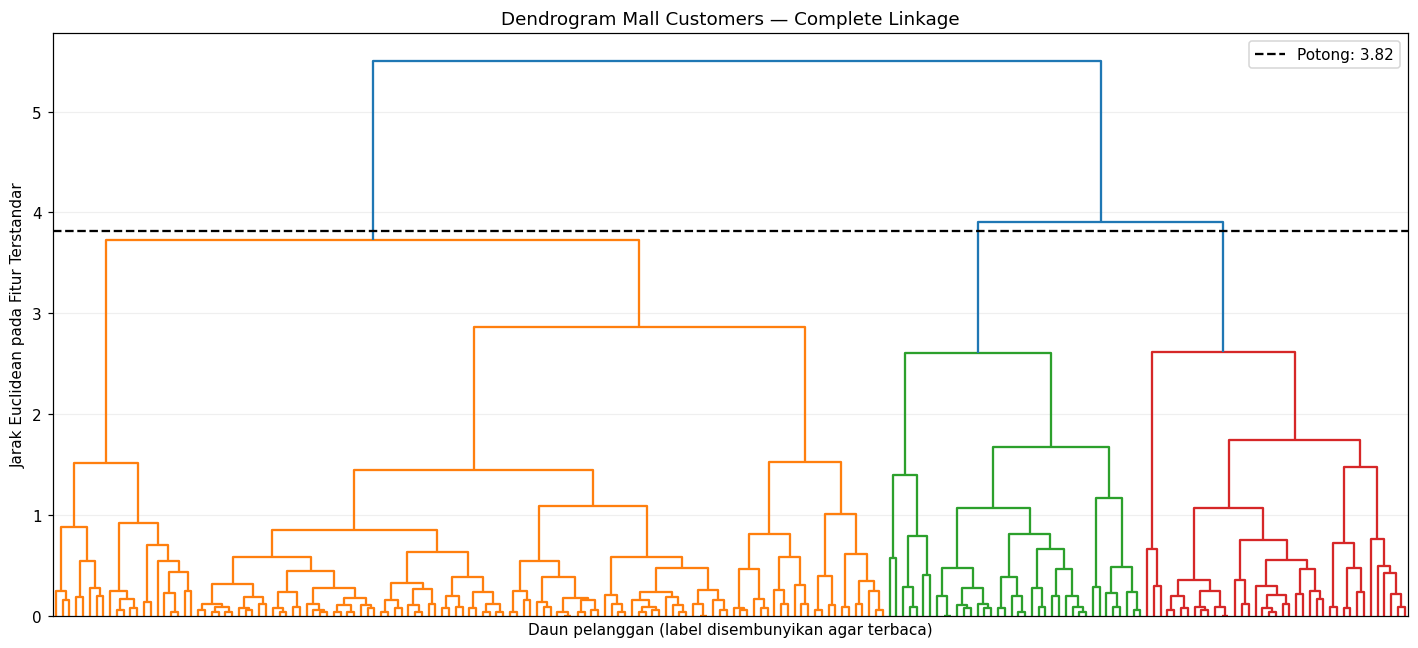

In [9]:
clustering = linkage(scaled_data, method="complete", metric="euclidean")
n_clusters = 3
if len(df) <= n_clusters:
    raise ValueError("Jumlah pelanggan harus lebih besar daripada jumlah klaster.")
lower_height = clustering[-n_clusters, 2]
upper_height = clustering[-(n_clusters - 1), 2]
if not lower_height < upper_height:
    raise ValueError("Tinggi penggabungan berimpit; garis potong tiga klaster tidak unik.")
cut_height = (lower_height + upper_height) / 2
print(f"Tinggi potong ilustratif untuk 3 klaster: {cut_height:.4f}")

fig, ax = plt.subplots(figsize=(13, 6))
dendrogram(clustering, no_labels=True, color_threshold=cut_height, ax=ax)
ax.axhline(cut_height, color="black", linestyle="--", label=f"Potong: {cut_height:.2f}")
ax.set(title="Dendrogram Mall Customers — Complete Linkage",
       xlabel="Daun pelanggan (label disembunyikan agar terbaca)",
       ylabel="Jarak Euclidean pada Fitur Terstandar")
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

### Dendrogram ringkas

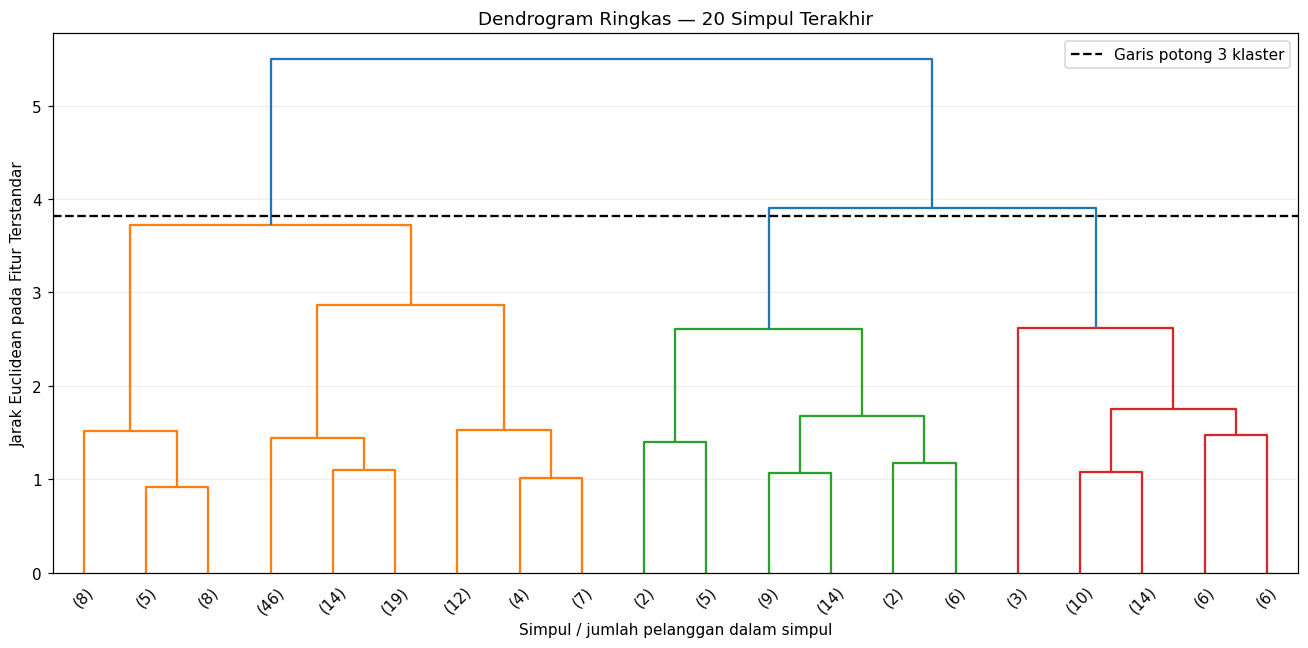

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(clustering, truncate_mode="lastp", p=20,
           show_leaf_counts=True, leaf_rotation=45,
           leaf_font_size=10, color_threshold=cut_height, ax=ax)
ax.axhline(cut_height, color="black", linestyle="--", label="Garis potong 3 klaster")
ax.set(title="Dendrogram Ringkas — 20 Simpul Terakhir",
       xlabel="Simpul / jumlah pelanggan dalam simpul",
       ylabel="Jarak Euclidean pada Fitur Terstandar")
ax.grid(axis="y", alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

## 9. Label klaster dan profil pelanggan
Hierarki dipotong menjadi tepat tiga klaster. Scatter plot memakai satuan asli agar profil pelanggan mudah dipahami. Nomor klaster hanya identitas, bukan peringkat atau kategori pengeluaran rendah/sedang/tinggi secara otomatis.

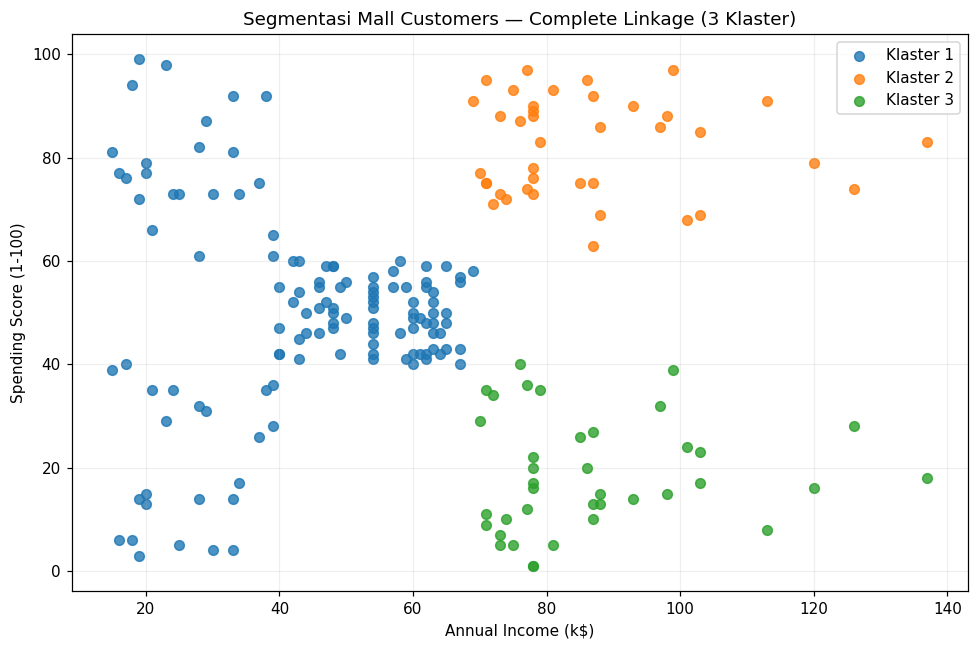

,Jumlah_Pelanggan,Rata_Income,Rata_Spending,Min_Spending,Max_Spending
Cluster,,,,,
1,123,44.15,49.83,3,99
2,39,86.54,82.13,63,97
3,38,87.00,18.63,1,40


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [11]:
df["Cluster"] = cut_tree(clustering, n_clusters=n_clusters).ravel() + 1
assert df["Cluster"].nunique() == n_clusters

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.get_cmap("tab10").colors
for cluster in sorted(df["Cluster"].unique()):
    group = df.loc[df["Cluster"] == cluster]
    ax.scatter(group[features[0]], group[features[1]], s=40, alpha=0.8,
               color=colors[cluster - 1], label=f"Klaster {cluster}")
ax.set(title="Segmentasi Mall Customers — Complete Linkage (3 Klaster)",
       xlabel="Annual Income (k$)", ylabel="Spending Score (1-100)")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()

summary = df.groupby("Cluster").agg(
    Jumlah_Pelanggan=("CustomerID", "size"),
    Rata_Income=("Annual Income (k$)", "mean"),
    Rata_Spending=("Spending Score (1-100)", "mean"),
    Min_Spending=("Spending Score (1-100)", "min"),
    Max_Spending=("Spending Score (1-100)", "max"),
)
display(summary.round(2))
assert summary["Jumlah_Pelanggan"].sum() == len(df)
display(df.head())

**Sel terakhir menyimpan hasil klasterisasi pelanggan dan ringkasan perbandingan metode.**

In [12]:
df.to_csv("Mall_Customers_Hasil_Hierarchical.csv", index=False)
comparison.to_csv("Perbandingan_Linkage_Dataset_Sederhana.csv", index=False)
print("Tersimpan: Mall_Customers_Hasil_Hierarchical.csv")
print("Tersimpan: Perbandingan_Linkage_Dataset_Sederhana.csv")

Tersimpan: Mall_Customers_Hasil_Hierarchical.csv
Tersimpan: Perbandingan_Linkage_Dataset_Sederhana.csv
